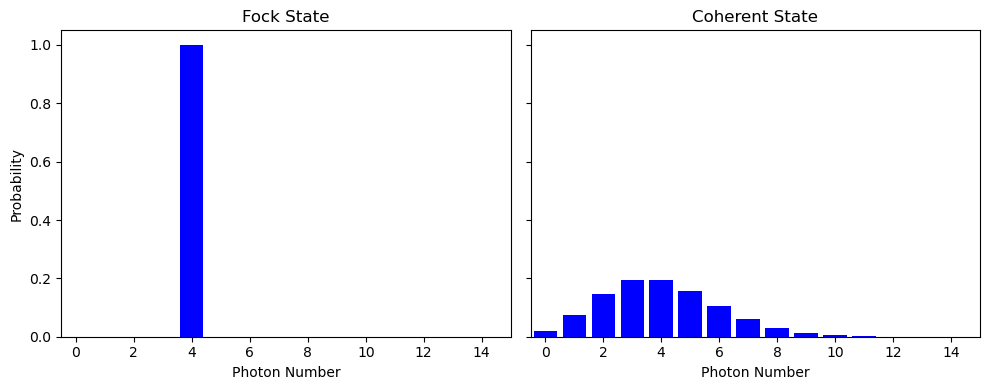

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameters
n_fock = 4      # Photon number for Fock state |n>
n_max = 15      # Range of photon numbers for plotting
mu = 4          # Mean photon number for coherent state

# Photon number axis
n_values = np.arange(0, n_max+1)

# Fock state distribution (delta function at n = n_fock)
fock_probs = np.zeros_like(n_values, dtype=float)
fock_probs[n_fock] = 1.0

# Coherent state distribution (Poisson with mean mu)
coherent_probs = poisson.pmf(n_values, mu)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Fock state plot
axes[0].bar(n_values, fock_probs, width=0.8, color='blue')
axes[0].set_title("Fock State")
axes[0].set_xlabel("Photon Number")
axes[0].set_ylabel("Probability")
axes[0].set_xlim(-0.5, n_max)

# Coherent state plot
axes[1].bar(n_values, coherent_probs, width=0.8, color='blue')
axes[1].set_title("Coherent State")
axes[1].set_xlabel("Photon Number")
axes[1].set_xlim(-0.5, n_max)

plt.tight_layout()
plt.show()


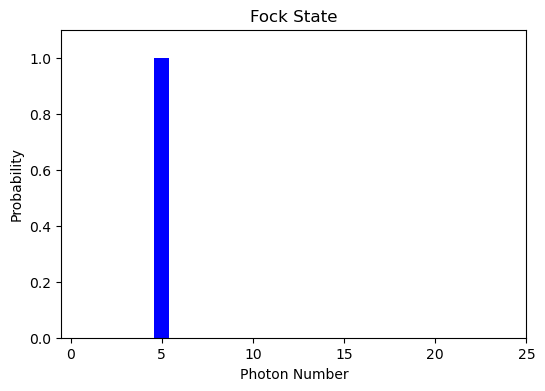

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_fock = 5        # Photon number for Fock state |n>
n_max = 25        # Range of photon numbers for plotting

# Photon number axis
n_values = np.arange(0, n_max+1)

# Fock state distribution (delta function at n = n_fock)
fock_probs = np.zeros_like(n_values, dtype=float)
fock_probs[n_fock] = 1.0

# Plot Fock state
plt.figure(figsize=(6,4))
plt.bar(n_values, fock_probs, width=0.8, color='blue')
plt.title("Fock State")
plt.xlabel("Photon Number")
plt.ylabel("Probability")
plt.xlim(-0.5, n_max)
plt.ylim(0, 1.1)
#plt.grid()
plt.show()


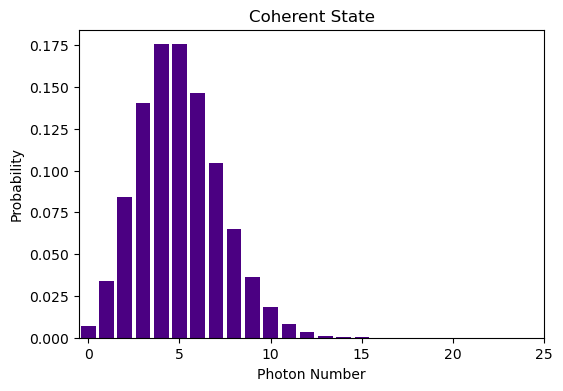

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameters
n_max = 25        # Range of photon numbers for plotting
mu = 5            # Mean photon number for coherent state

# Photon number axis
n_values = np.arange(0, n_max+1)

# Coherent state distribution (Poisson with mean mu)
coherent_probs = poisson.pmf(n_values, mu)

# Plot Coherent state
plt.figure(figsize=(6,4))
plt.bar(n_values, coherent_probs, width=0.8, color='indigo')
plt.title("Coherent State")
plt.xlabel("Photon Number")
plt.ylabel("Probability")

plt.xlim(-0.5, n_max)
plt.show()


--- Analysis of Provided g2(0) Values ---
Data Points: [1.02266658, 1.01680593, 1.01101563, 1.00105996, 1.02533721, 1.02022313, 1.01870727, 1.0190979, 1.01868641, 2.05939568]
Number of runs: 10
Average g2(0): 1.1213
Standard Deviation of g2(0): 0.3128

Interpretation:
The average g2(0) value is >= 1, which is consistent with the behavior of a classical light source (e.g., a laser or LED).
The final data point (g2(0) > 2) is a clear indication of photon bunching, which is characteristic of a thermal light source, especially with the aperture fully open.


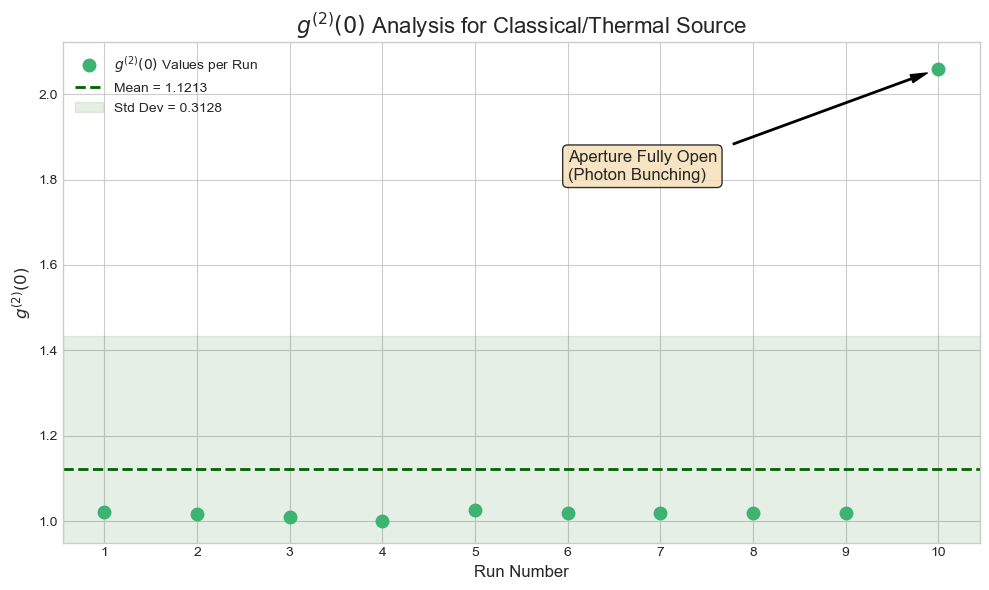

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_g2_data():
    """
    Analyzes and plots a given list of g2(0) values for what appears to be
    a classical or coherent light source.
    """
    # The g2(0) values you provided
    g2_values = [
        1.02266658, 1.01680593, 1.01101563, 1.00105996,
        1.02533721, 1.02022313, 1.01870727, 1.0190979,
        1.01868641, 2.05939568  # This last value corresponds to the fully open aperture
    ]
    
    # Create a simple run number for the x-axis
    run_numbers = np.arange(1, len(g2_values) + 1)

    # --- Calculations ---
    mean_g2 = np.mean(g2_values)
    std_g2 = np.std(g2_values)

    # --- Print Results to Console ---
    print("--- Analysis of Provided g2(0) Values ---")
    print(f"Data Points: {g2_values}")
    print(f"Number of runs: {len(g2_values)}")
    print(f"Average g2(0): {mean_g2:.4f}")
    print(f"Standard Deviation of g2(0): {std_g2:.4f}")
    print("\nInterpretation:")
    print("The average g2(0) value is >= 1, which is consistent with the behavior of a classical light source (e.g., a laser or LED).")
    print("The final data point (g2(0) > 2) is a clear indication of photon bunching, which is characteristic of a thermal light source, especially with the aperture fully open.")


    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each data point
    ax.plot(run_numbers, g2_values, 'o', color='mediumseagreen', markersize=9, label='$g^{(2)}(0)$ Values per Run')

    # Plot the mean and standard deviation
    ax.axhline(mean_g2, color='darkgreen', linestyle='--', linewidth=2, label=f'Mean = {mean_g2:.4f}')
    ax.axhspan(mean_g2 - std_g2, mean_g2 + std_g2, color='darkgreen', alpha=0.1, label=f'Std Dev = {std_g2:.4f}')
    
    # Annotate the significant last point
    ax.annotate(
        'Aperture Fully Open\n(Photon Bunching)', 
        xy=(10, 2.059), 
        xytext=(6, 1.8),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", fc="wheat", ec="black", lw=1, alpha=0.8)
    )

    # --- Formatting ---
    ax.set_xlabel('Run Number', fontsize=12)
    ax.set_ylabel('$g^{(2)}(0)$', fontsize=12)
    ax.set_title('$g^{(2)}(0)$ Analysis for Classical/Thermal Source', fontsize=16)
    ax.legend(loc='best', fontsize=10)
    ax.set_xticks(run_numbers) # Ensure every run number is marked on the x-axis
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Set y-axis limits to better visualize the data spread
    ax.set_ylim(bottom=0.95)

    # Display the plot
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    analyze_g2_data()


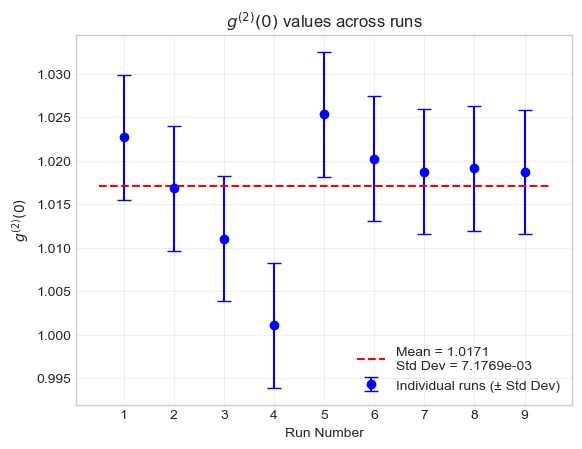

Mean g2(0): 1.017067
Variance: 5.150787e-05
Standard Deviation: 7.176898e-03


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# g2(0) values for each run
g2_values = np.array([
    1.02266658,
    1.01680593,
    1.01101563,
    1.00105996,
    1.02533721,
    1.02022313,
    1.01870727,
    1.0190979,
    1.01868641
])

# Calculate statistics
mean_val = np.mean(g2_values)
variance_val = np.var(g2_values, ddof=1)  # sample variance
std_dev = np.std(g2_values, ddof=1)       # sample standard deviation

# x-axis for runs
x = np.arange(1, len(g2_values) + 1)

# Plot data points with error bars
plt.errorbar(x, g2_values, yerr=std_dev, fmt='o', color='blue', capsize=5,
             label="Individual runs (± Std Dev)")

# Plot mean line
plt.hlines(mean_val, xmin=0.5, xmax=len(g2_values)+0.5, colors='red', linestyles='--',
           label=f"Mean = {mean_val:.4f}\nStd Dev = {std_dev:.4e}")

# Labels and formatting
plt.title(r"$g^{(2)}(0)$ values across runs")
plt.xlabel("Run Number")
plt.ylabel(r"$g^{(2)}(0)$")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

# Print results
print(f"Mean g2(0): {mean_val:.6f}")
print(f"Variance: {variance_val:.6e}")
print(f"Standard Deviation: {std_dev:.6e}")


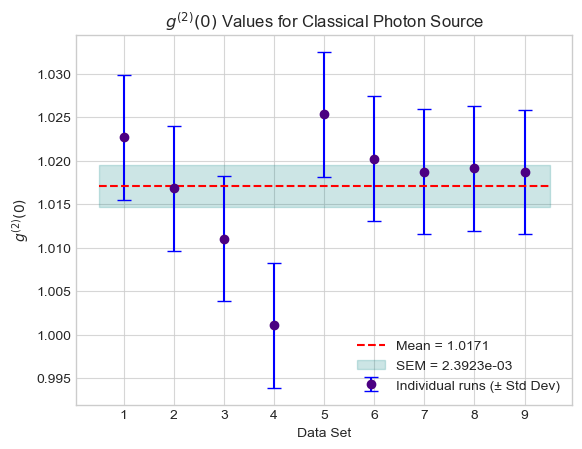

Mean g2(0): 1.017067
Variance: 5.150787e-05
Standard Deviation: 7.176898e-03
Standard Error of Mean (SEM): 2.392299e-03


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# g2(0) values for each run
g2_values = np.array([
    1.02266658,
    1.01680593,
    1.01101563,
    1.00105996,
    1.02533721,
    1.02022313,
    1.01870727,
    1.0190979,
    1.01868641
])

# Calculate statistics
N = len(g2_values)
mean_val = np.mean(g2_values)
variance_val = np.var(g2_values, ddof=1)   # sample variance
std_dev = np.std(g2_values, ddof=1)        # sample standard deviation
sem = std_dev / np.sqrt(N)                 # standard error of the mean

# x-axis for runs
x = np.arange(1, N + 1)

# Plot individual data points with error bars (std dev per point)
plt.errorbar(x, g2_values, yerr=std_dev, fmt='o', color='indigo', ecolor='blue',
             elinewidth=1.5, capsize=5, label="Individual runs (± Std Dev)")

# Plot mean with SEM band
plt.hlines(mean_val, xmin=0.5, xmax=N+0.5, colors='red', linestyles='--',
           label=f"Mean = {mean_val:.4f}")
plt.fill_between([0.5, N+0.5], mean_val-sem, mean_val+sem, color='teal', alpha=0.2,
                 label=f"SEM = {sem:.4e}")

# Labels and formatting
plt.title(r"$g^{(2)}(0)$ Values for Classical Photon Source")
plt.xlabel("Data Set")
plt.ylabel(r"$g^{(2)}(0)$")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.8)

# Show plot
plt.show()

# Print results
print(f"Mean g2(0): {mean_val:.6f}")
print(f"Variance: {variance_val:.6e}")
print(f"Standard Deviation: {std_dev:.6e}")
print(f"Standard Error of Mean (SEM): {sem:.6e}")


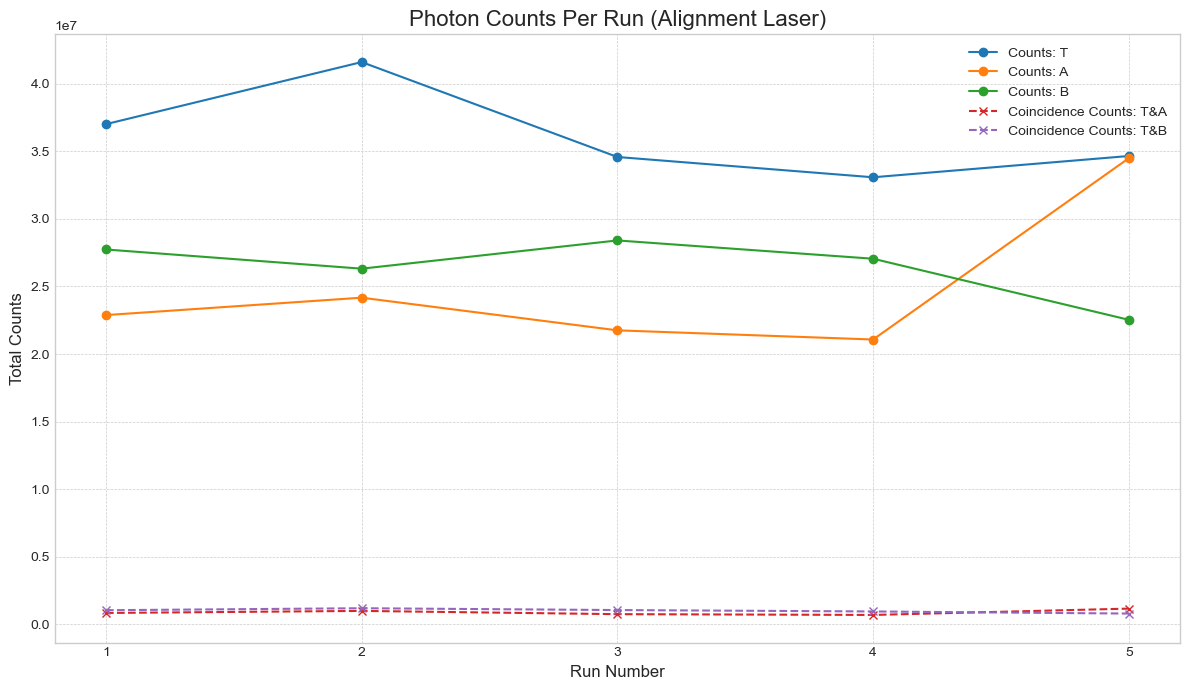

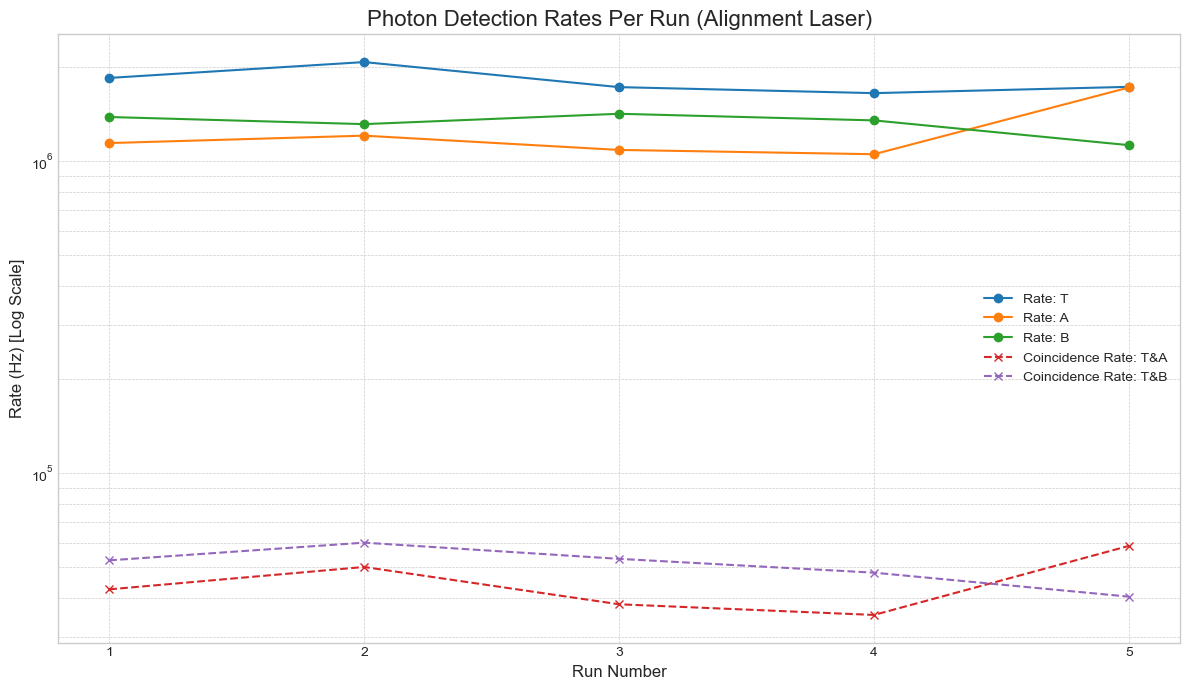

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the full path to your data file
# Note: We use double backslashes "\\" or a raw string r"..." for Windows paths
file_path = r"C:\Users\Shagnik\Downloads\GRA_Algnmnt Laser.csv"

try:
    # Load your data using the specified filepath
    df_raw = pd.read_csv(file_path)

    # --- Data Cleaning and Structuring ---
    # The CSV structure is unconventional, so we need to parse it carefully.
    # The data for each run is spread across columns.
    data_rows = {
        "Rates (Hz): T": [], "Rates (Hz): A": [], "Rates (Hz): B": [],
        "Rates (Hz): T&A": [], "Rates (Hz): T&B": [],
        "Counts: T": [], "Counts: A": [], "Counts: B": [],
        "Counts: T&A": [], "Counts: T&B": []
    }

    # Iterate through the columns in steps of 2 to get data for each run
    for i in range(0, len(df_raw.columns), 2):
        col_label = df_raw.columns[i]
        col_value = df_raw.columns[i+1]
        
        # Extract data for each metric based on its label in the first column of a pair
        for key in data_rows.keys():
            # Find the row where the label matches our key
            row = df_raw[df_raw[col_label] == key]
            if not row.empty:
                # Get the corresponding value from the next column
                value = row.iloc[0][col_value]
                data_rows[key].append(float(value))

    # Create a new, clean DataFrame from the parsed data
    df = pd.DataFrame(data_rows)
    
    # --- Plotting ---
    
    runs = df.index + 1  # Create run numbers (1, 2, 3, ...)


    # Plotting Counts
    fig1, ax1 = plt.subplots(figsize=(12, 7))
    ax1.plot(runs, df["Counts: T"], marker='o', linestyle='-', label="Counts: T")
    ax1.plot(runs, df["Counts: A"], marker='o', linestyle='-', label="Counts: A")
    ax1.plot(runs, df["Counts: B"], marker='o', linestyle='-', label="Counts: B")
    ax1.plot(runs, df["Counts: T&A"], marker='x', linestyle='--', label="Coincidence Counts: T&A")
    ax1.plot(runs, df["Counts: T&B"], marker='x', linestyle='--', label="Coincidence Counts: T&B")
    
    ax1.set_xlabel("Run Number", fontsize=12)
    ax1.set_ylabel("Total Counts", fontsize=12)
    ax1.set_title("Photon Counts Per Run (Alignment Laser)", fontsize=16)
    ax1.legend(fontsize=10)
    ax1.set_xticks(runs)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    # Plotting Rates
    fig2, ax2 = plt.subplots(figsize=(12, 7))
    ax2.plot(runs, df["Rates (Hz): T"], marker='o', linestyle='-', label="Rate: T")
    ax2.plot(runs, df["Rates (Hz): A"], marker='o', linestyle='-', label="Rate: A")
    ax2.plot(runs, df["Rates (Hz): B"], marker='o', linestyle='-', label="Rate: B")
    ax2.plot(runs, df["Rates (Hz): T&A"], marker='x', linestyle='--', label="Coincidence Rate: T&A")
    ax2.plot(runs, df["Rates (Hz): T&B"], marker='x', linestyle='--', label="Coincidence Rate: T&B")
    
    ax2.set_xlabel("Run Number", fontsize=12)
    ax2.set_ylabel("Rate (Hz) [Log Scale]", fontsize=12)
    ax2.set_title("Photon Detection Rates Per Run (Alignment Laser)", fontsize=16)
    ax2.legend(fontsize=10)
    ax2.set_xticks(runs)
    ax2.set_yscale('log')  # Use a log scale to better visualize the smaller coincidence rates
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: The file was not found at the path '{file_path}'.")
    print("Please ensure the file path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred while processing the file: {e}")


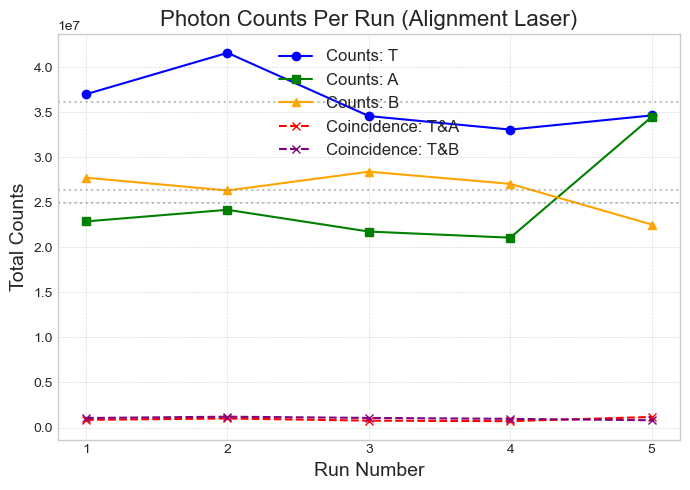

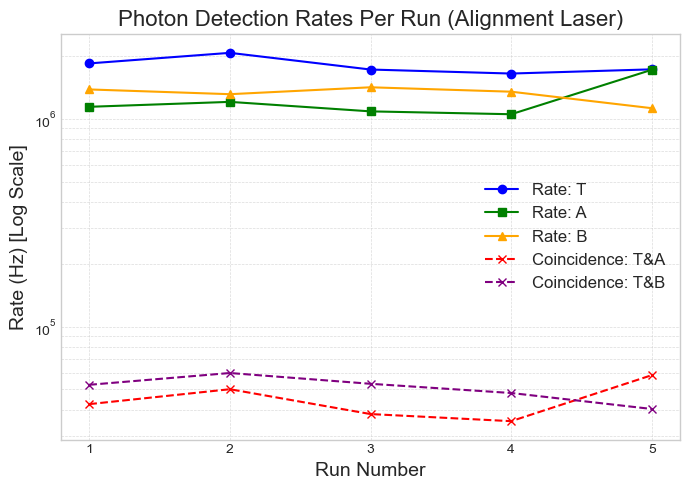

In [12]:
import numpy as np

runs = df.index + 1

# --- Plotting Counts ---
fig1, ax1 = plt.subplots(figsize=(7, 5))

# Singles
ax1.plot(runs, df["Counts: T"], marker='o', linestyle='-', color='blue', label="Counts: T")
ax1.plot(runs, df["Counts: A"], marker='s', linestyle='-', color='green', label="Counts: A")
ax1.plot(runs, df["Counts: B"], marker='^', linestyle='-', color='orange', label="Counts: B")

# Coincidences
ax1.plot(runs, df["Counts: T&A"], marker='x', linestyle='--', color='red', label="Coincidence: T&A")
ax1.plot(runs, df["Counts: T&B"], marker='x', linestyle='--', color='purple', label="Coincidence: T&B")

# Mean lines for stability check
for col in ["Counts: T", "Counts: A", "Counts: B"]:
    mean_val = np.mean(df[col])
    ax1.axhline(mean_val, linestyle=':', color='gray', alpha=0.5)

ax1.set_xlabel("Run Number", fontsize=14)
ax1.set_ylabel("Total Counts", fontsize=14)
ax1.set_title("Photon Counts Per Run (Alignment Laser)", fontsize=16)
ax1.legend(fontsize=12)
ax1.set_xticks(runs)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


# --- Plotting Rates ---
fig2, ax2 = plt.subplots(figsize=(7, 5))

# Singles (linear scale)
ax2.plot(runs, df["Rates (Hz): T"], marker='o', linestyle='-', color='blue', label="Rate: T")
ax2.plot(runs, df["Rates (Hz): A"], marker='s', linestyle='-', color='green', label="Rate: A")
ax2.plot(runs, df["Rates (Hz): B"], marker='^', linestyle='-', color='orange', label="Rate: B")

# Coincidences (log scale)
ax2.plot(runs, df["Rates (Hz): T&A"], marker='x', linestyle='--', color='red', label="Coincidence: T&A")
ax2.plot(runs, df["Rates (Hz): T&B"], marker='x', linestyle='--', color='purple', label="Coincidence: T&B")

# Log scale for coincidences only (optional: add secondary axis)
ax2.set_yscale('log')
ax2.set_xlabel("Run Number", fontsize=14)
ax2.set_ylabel("Rate (Hz) [Log Scale]", fontsize=14)
ax2.set_title("Photon Detection Rates Per Run (Alignment Laser)", fontsize=16)
ax2.legend(fontsize=12)
ax2.set_xticks(runs)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


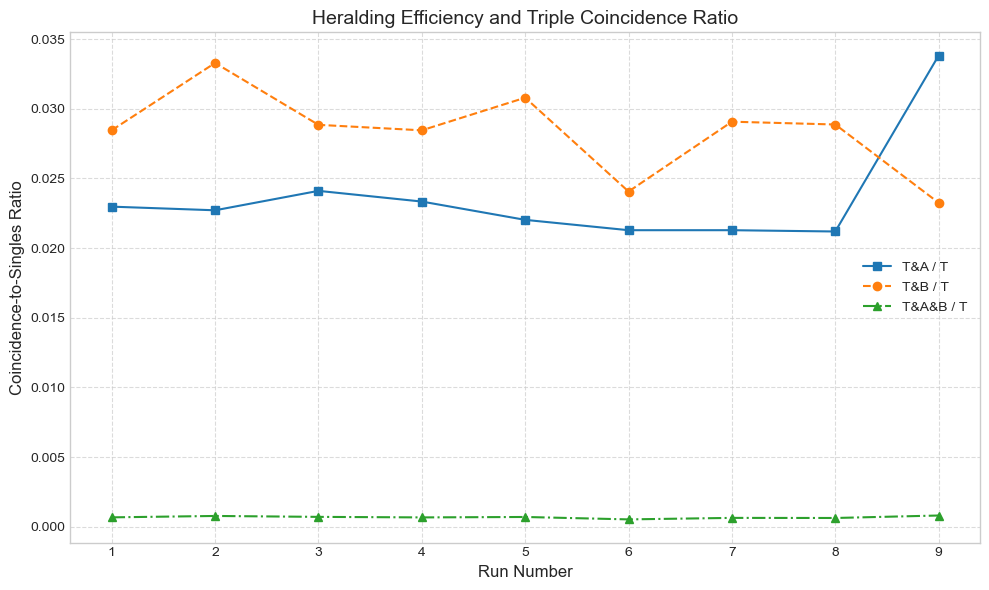

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for 9 runs
data = {
    "Rates (Hz): T": [
        1850302.05, 1786891.25, 2079898.1, 1984617.4, 1728857.65,
        1672579.45, 1653820.5, 1643270.3, 1732503.1
    ],
    "Rates (Hz): A": [
        1144163.1, 1121899.85, 1208523.85, 1163227.7, 1087740.9,
        1060122.05, 1053821, 1049732.65, 1724498.4
    ],
    "Rates (Hz): B": [
        1386757.4, 1537926.6, 1315832.1, 1302936.7, 1420241.6,
        1181475.9, 1352577.85, 1348295.4, 1126673.4
    ],
    "Rates (Hz): T&A": [
        42508.1, 40583.85, 50139.95, 46320, 38078.45,
        35597.3, 35198.55, 34820.7, 58597.35
    ],
    "Rates (Hz): T&B": [
        52655.25, 59483.8, 59998, 56468.75, 53240.75,
        40242.65, 48080.55, 47442.5, 40283.7
    ],
    "Rates (Hz): T&A&B": [
        1237.1, 1373.7, 1462.3, 1319.35, 1202.35,
        873.8, 1042.45, 1024.5, 1387.95
    ]
}

# Create DataFrame
df = pd.DataFrame(data)
runs = df.index + 1  # Run numbers 1 to 9

# Compute coincidence-to-singles ratios
df["Ratio_TA_over_T"] = df["Rates (Hz): T&A"] / df["Rates (Hz): T"]
df["Ratio_TB_over_T"] = df["Rates (Hz): T&B"] / df["Rates (Hz): T"]
df["Ratio_TAB_over_T"] = df["Rates (Hz): T&A&B"] / df["Rates (Hz): T"]

# Plotting
plt.figure(figsize=(10,6))
plt.plot(runs, df["Ratio_TA_over_T"], marker='s', linestyle='-', label="T&A / T")
plt.plot(runs, df["Ratio_TB_over_T"], marker='o', linestyle='--', label="T&B / T")
plt.plot(runs, df["Ratio_TAB_over_T"], marker='^', linestyle='-.', label="T&A&B / T")

plt.xlabel("Run Number", fontsize=12)
plt.ylabel("Coincidence-to-Singles Ratio", fontsize=12)
plt.title("Heralding Efficiency and Triple Coincidence Ratio", fontsize=14)
plt.xticks(runs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


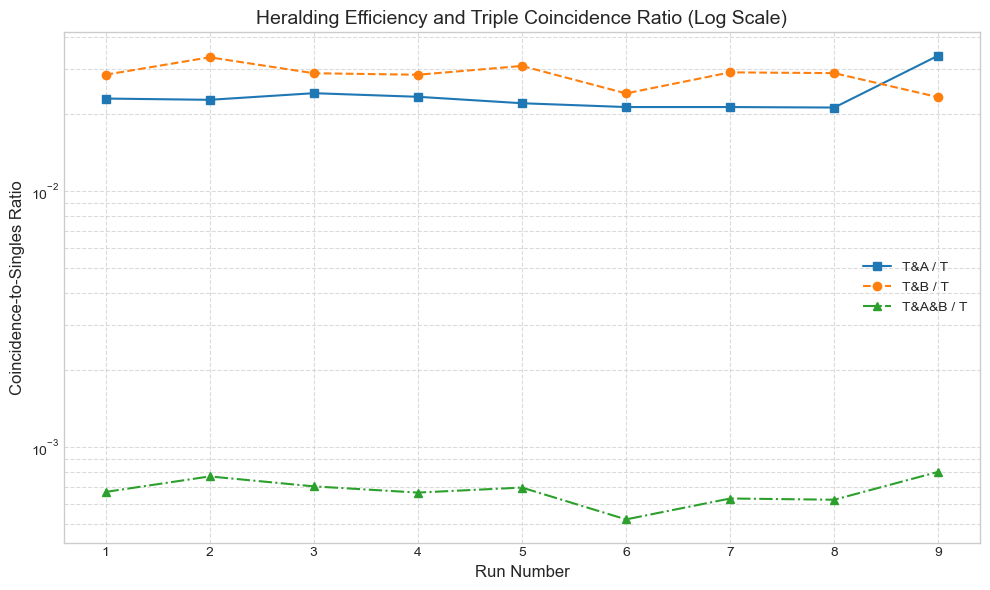

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Data for 9 runs
data = {
    "Rates (Hz): T": [
        1850302.05, 1786891.25, 2079898.1, 1984617.4, 1728857.65,
        1672579.45, 1653820.5, 1643270.3, 1732503.1
    ],
    "Rates (Hz): T&A": [
        42508.1, 40583.85, 50139.95, 46320, 38078.45,
        35597.3, 35198.55, 34820.7, 58597.35
    ],
    "Rates (Hz): T&B": [
        52655.25, 59483.8, 59998, 56468.75, 53240.75,
        40242.65, 48080.55, 47442.5, 40283.7
    ],
    "Rates (Hz): T&A&B": [
        1237.1, 1373.7, 1462.3, 1319.35, 1202.35,
        873.8, 1042.45, 1024.5, 1387.95
    ]
}

# Create DataFrame
df = pd.DataFrame(data)
runs = df.index + 1  # Run numbers 1 to 9

# Compute coincidence-to-singles ratios
df["Ratio_TA_over_T"] = df["Rates (Hz): T&A"] / df["Rates (Hz): T"]
df["Ratio_TB_over_T"] = df["Rates (Hz): T&B"] / df["Rates (Hz): T"]
df["Ratio_TAB_over_T"] = df["Rates (Hz): T&A&B"] / df["Rates (Hz): T"]

# Plotting with log scale
plt.figure(figsize=(10,6))
plt.plot(runs, df["Ratio_TA_over_T"], marker='s', linestyle='-', label="T&A / T")
plt.plot(runs, df["Ratio_TB_over_T"], marker='o', linestyle='--', label="T&B / T")
plt.plot(runs, df["Ratio_TAB_over_T"], marker='^', linestyle='-.', label="T&A&B / T")

plt.xlabel("Run Number", fontsize=12)
plt.ylabel("Coincidence-to-Singles Ratio", fontsize=12)
plt.title("Heralding Efficiency and Triple Coincidence Ratio (Log Scale)", fontsize=14)
plt.xticks(runs)
plt.yscale('log')  # Log scale to visualize small triple coincidences
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


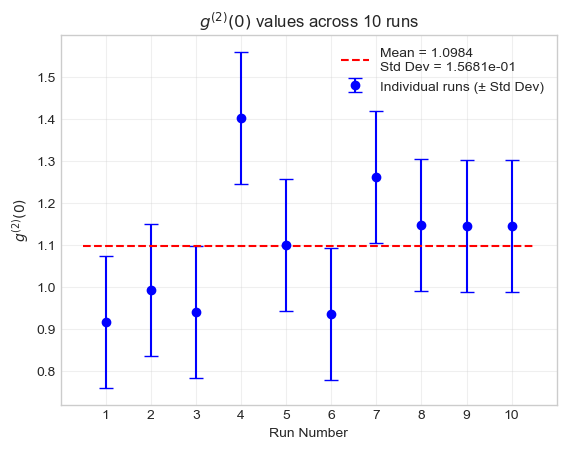

Mean g2(0): 1.098380
Variance: 2.459036e-02
Standard Deviation: 1.568131e-01


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# g2(0) values for 10 runs
g2_values = np.array([
    0.917262902,
    0.992117353,
    0.939754464,
    1.40203877,
    1.09987004,
    0.934863057,
    1.26083388,
    1.14652621,
    1.1445903,
    1.14594697
])

# Calculate statistics
mean_val = np.mean(g2_values)
variance_val = np.var(g2_values, ddof=1)  # sample variance
std_dev = np.std(g2_values, ddof=1)       # sample standard deviation

# x-axis for runs
x = np.arange(1, len(g2_values) + 1)

# Plot data points with error bars
plt.errorbar(x, g2_values, yerr=std_dev, fmt='o', color='blue', capsize=5,
             label="Individual runs (± Std Dev)")

# Plot mean line
plt.hlines(mean_val, xmin=0.5, xmax=len(g2_values)+0.5, colors='red', linestyles='--',
           label=f"Mean = {mean_val:.4f}\nStd Dev = {std_dev:.4e}")

# Labels and formatting
plt.title(r"$g^{(2)}(0)$ values across 10 runs")
plt.xlabel("Run Number")
plt.ylabel(r"$g^{(2)}(0)$")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

# Print results
print(f"Mean g2(0): {mean_val:.6f}")
print(f"Variance: {variance_val:.6e}")
print(f"Standard Deviation: {std_dev:.6e}")


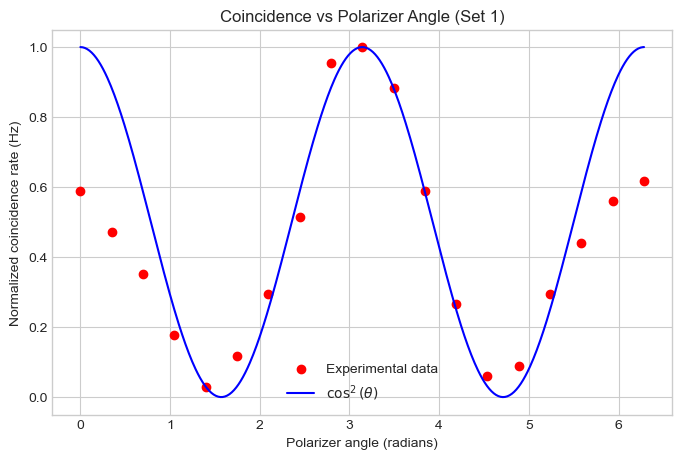

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- Replace these with your actual data (entered in radians) ---
# Example angles in radians (0 → 2π)
angles_rad = np.deg2rad(np.array([0, 20, 40, 60, 80, 100, 120, 140, 
                                  160, 180, 200, 220, 240, 260, 
                                  280, 300, 320, 340, 360]))

# Example coincidence rates (Hz) – replace with actual values
coinc_rates = np.array([400, 320, 240, 120, 20, 80, 200, 350, 650, 680,
                        600, 400, 180, 40, 60, 200, 300, 380, 420])

# Normalize for comparison
coinc_rates_norm = coinc_rates / np.max(coinc_rates)

# Theoretical Malus law: I = cos^2(theta)
theta = np.linspace(0, 2*np.pi, 500)
malus_curve = np.cos(theta)**2

# --- Plot ---
plt.figure(figsize=(8,5))
plt.scatter(angles_rad, coinc_rates_norm, color='red', label="Experimental data")
plt.plot(theta, malus_curve, color='blue', label=r"$\cos^2(\theta)$ ")

plt.xlabel("Polarizer angle (radians)")
plt.ylabel("Normalized coincidence rate (Hz)")
plt.title("Coincidence vs Polarizer Angle (Set 1)")
plt.legend()
plt.grid(True)
plt.show()


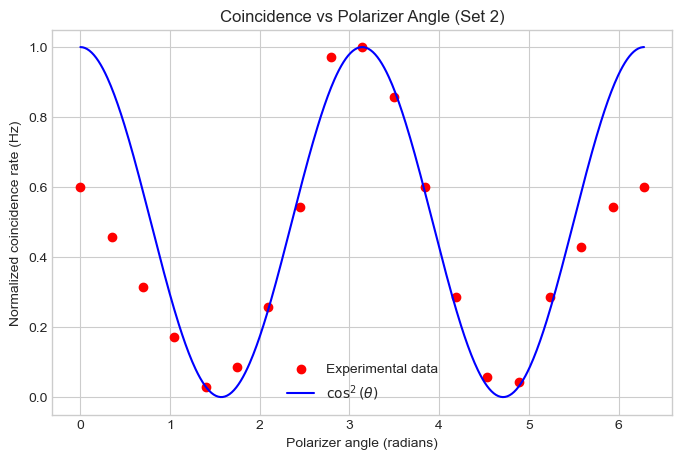

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Replace these with extracted data from the screenshot
# -----------------------------
angles_deg = np.array([0, 20, 40, 60, 80, 100, 120, 140,
                       160, 180, 200, 220, 240, 260, 
                       280, 300, 320, 340, 360])

# Example coincidence rates (Hz) from red curve
coinc_rates = np.array([420, 320, 220, 120, 20, 60, 180, 380, 
                        680, 700, 600, 420, 200, 40, 30, 200, 
                        300, 380, 420])

# Example g2(0) values (green curve)
g2_values = np.array([0.02, 0.03, 0.04, 0.05, 0.75, 0.04, 0.05, 0.02, 
                      0.01, 0.02, 0.03, 0.05, 0.04, 0.25, 0.02, 0.01, 
                      0.02, 0.01, 0.02])

# Convert angles to radians
angles_rad = np.deg2rad(angles_deg)

# Normalize coincidence data
coinc_rates_norm = coinc_rates / np.max(coinc_rates)

# Theoretical Malus law curve
theta = np.linspace(0, 2*np.pi, 500)
malus_curve = np.cos(theta)**2

# -----------------------------
# Plot coincidence vs angle
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(angles_rad, coinc_rates_norm, color='red', label="Experimental data")
plt.plot(theta, malus_curve, color='blue', label=r"$\cos^2(\theta)$ ")

plt.xlabel("Polarizer angle (radians)")
plt.ylabel("Normalized coincidence rate (Hz)")
plt.title("Coincidence vs Polarizer Angle (Set 2)")
plt.legend()
plt.grid(True)
plt.show()



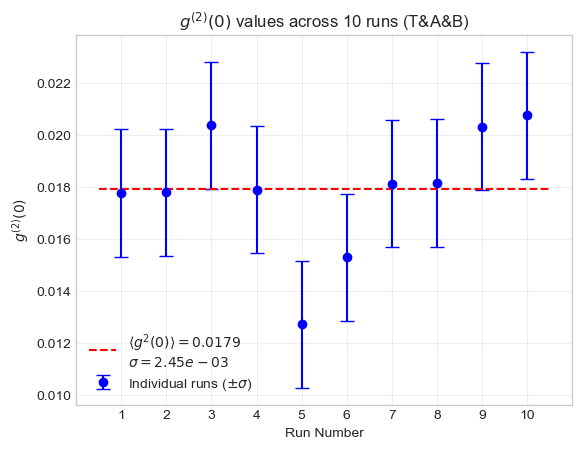

Mean $g^2(0)$: 0.017932
Variance: 5.992583e-06
Standard Deviation ($\sigma$): 2.447975e-03


In [27]:
import numpy as np
import matplotlib.pyplot as plt

# g2(0) values for 10 runs (T&A&B)
g2_values = np.array([
    0.0177783772,
    0.0178090497,
    0.0203896880,
    0.0179098205,
    0.0127267137,
    0.0153088140,
    0.0181382832,
    0.0181647665,
    0.0203304784,
    0.0207654197
])

# Calculate statistics
mean_val = np.mean(g2_values)
variance_val = np.var(g2_values, ddof=1)  # sample variance
std_dev = np.std(g2_values, ddof=1)       # sample standard deviation

# x-axis for runs
x = np.arange(1, len(g2_values) + 1)

# Plot data points with error bars
plt.errorbar(x, g2_values, yerr=std_dev, fmt='o', color='blue', capsize=5,
             label=r"Individual runs ($\pm \sigma$)")

# Plot mean line
plt.hlines(mean_val, xmin=0.5, xmax=len(g2_values)+0.5, colors='red', linestyles='--',
           label=fr"$\langle g^{(2)}(0) \rangle = {mean_val:.4f}$" + "\n" + fr"$\sigma = {std_dev:.2e}$")

# Labels and formatting
plt.title(r"$g^{(2)}(0)$ values across 10 runs (T&A&B)")
plt.xlabel("Run Number")
plt.ylabel(r"$g^{(2)}(0)$")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

# Print results
print(fr"Mean $g^{(2)}(0)$: {mean_val:.6f}")
print(fr"Variance: {variance_val:.6e}")
print(fr"Standard Deviation ($\sigma$): {std_dev:.6e}")


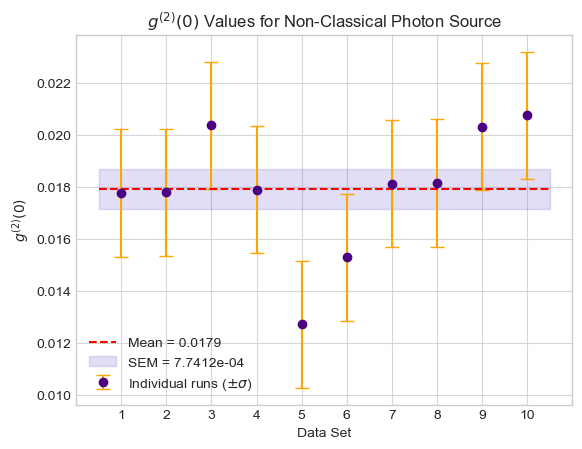

Mean g2(0): 0.017932
Variance: 5.992583e-06
($\sigma$): 2.447975e-03
Standard Error of Mean (SEM): 7.741178e-04


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# g2(0) values for each run
g2_values = np.array([
    0.0177783772,
    0.0178090497,
    0.0203896880,
    0.0179098205,
    0.0127267137,
    0.0153088140,
    0.0181382832,
    0.0181647665,
    0.0203304784,
    0.0207654197
])

# Calculate statistics
N = len(g2_values)
mean_val = np.mean(g2_values)
variance_val = np.var(g2_values, ddof=1)   # sample variance
std_dev = np.std(g2_values, ddof=1)        # sample standard deviation
sem = std_dev / np.sqrt(N)                 # standard error of the mean

# x-axis for runs
x = np.arange(1, N + 1)

# Plot individual data points with error bars (std dev per point)
plt.errorbar(x, g2_values, yerr=std_dev, fmt='o', color='indigo', ecolor='orange',
             elinewidth=1.5, capsize=5, label="Individual runs ($\pm \sigma$)")

# Plot mean with SEM band
plt.hlines(mean_val, xmin=0.5, xmax=N+0.5, colors='red', linestyles='--',
           label=f"Mean = {mean_val:.4f}")
plt.fill_between([0.5, N+0.5], mean_val-sem, mean_val+sem, color='slateblue', alpha=0.2,
                 label=f"SEM = {sem:.4e}")

# Labels and formatting
plt.title(r"$g^{(2)}(0)$ Values for Non-Classical Photon Source")
plt.xlabel("Data Set")
plt.ylabel(r"$g^{(2)}(0)$")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.8)

# Show plot
plt.show()

# Print results
print(f"Mean g2(0): {mean_val:.6f}")
print(f"Variance: {variance_val:.6e}")
print(f"($\sigma$): {std_dev:.6e}")
print(f"Standard Error of Mean (SEM): {sem:.6e}")


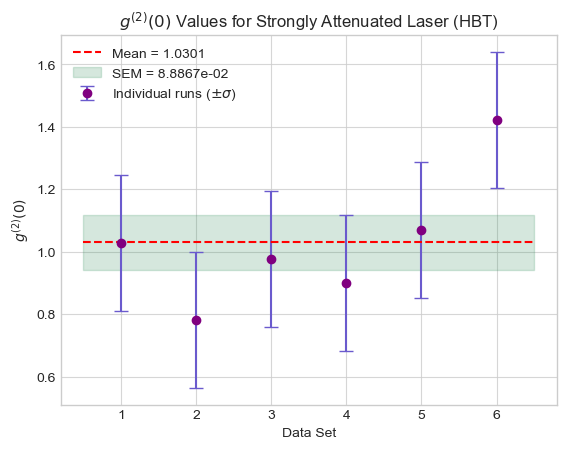

Mean g2(0): 1.030070
Variance: 4.738455e-02
($\sigma$): 2.176799e-01
Standard Error of Mean (SEM): 8.886746e-02


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# g2(0) values for each run
g2_values = np.array([
   1.02812685,  
0.782322992,  
0.97688211,  
0.90009825,  
1.07022673,  
1.422761  
])

# Calculate statistics
N = len(g2_values)
mean_val = np.mean(g2_values)
variance_val = np.var(g2_values, ddof=1)   # sample variance
std_dev = np.std(g2_values, ddof=1)        # sample standard deviation
sem = std_dev / np.sqrt(N)                 # standard error of the mean

# x-axis for runs
x = np.arange(1, N + 1)

# Plot individual data points with error bars (std dev per point)
plt.errorbar(x, g2_values, yerr=std_dev, fmt='o', color='purple', ecolor='slateblue',
             elinewidth=1.5, capsize=5, label="Individual runs ($\pm \sigma$)")

# Plot mean with SEM band
plt.hlines(mean_val, xmin=0.5, xmax=N+0.5, colors='red', linestyles='--',
           label=f"Mean = {mean_val:.4f}")
plt.fill_between([0.5, N+0.5], mean_val-sem, mean_val+sem, color='seagreen', alpha=0.2,
                 label=f"SEM = {sem:.4e}")

# Labels and formatting
plt.title(r"$g^{(2)}(0)$ Values for Strongly Attenuated Laser (HBT)")
plt.xlabel("Data Set")
plt.ylabel(r"$g^{(2)}(0)$")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.8)

# Show plot
plt.show()

# Print results
print(f"Mean g2(0): {mean_val:.6f}")
print(f"Variance: {variance_val:.6e}")
print(f"($\sigma$): {std_dev:.6e}")
print(f"Standard Error of Mean (SEM): {sem:.6e}")


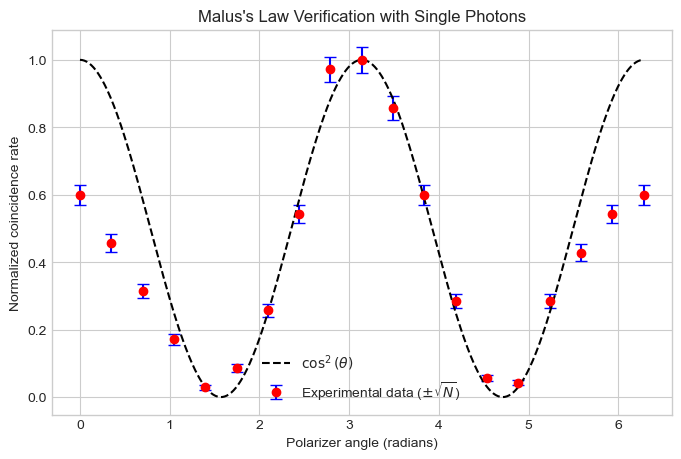

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Polarizer angles (deg) and coincidence counts (raw data you gave)
angles_deg = np.array([0, 20, 40, 60, 80, 100, 120, 140,
                       160, 180, 200, 220, 240, 260, 
                       280, 300, 320, 340, 360])

coinc_counts = np.array([420, 320, 220, 120, 20, 60, 180, 380, 
                         680, 700, 600, 420, 200, 40, 30, 200, 
                         300, 380, 420])

# Normalize counts
N_max = np.max(coinc_counts)
coinc_rates_norm = coinc_counts / N_max

# Poisson error: sqrt(N), normalized
error_norm = np.sqrt(coinc_counts) / N_max

# Theoretical Malus law curve
theta = np.linspace(0, 2*np.pi, 500)
malus_curve = np.cos(theta)**2

# Plot with error bars
plt.figure(figsize=(8,5))
plt.errorbar(np.deg2rad(angles_deg), coinc_rates_norm, 
             yerr=error_norm, fmt='o', color='red', 
             ecolor='blue', capsize=4, label="Experimental data ($\pm \sqrt{N}$)")

plt.plot(theta, malus_curve, color='black', linestyle='--', label=r"$\cos^2(\theta)$")

plt.xlabel("Polarizer angle (radians)")
plt.ylabel("Normalized coincidence rate")
plt.title("Malus's Law Verification with Single Photons")
plt.legend()
plt.grid(True)
plt.show()
